# Process Flow: Full Model and Split by PROCESSAREA

Loads `processflow_export_2.xes` and:

1. Discovers a **directly-follows graph** and a **Split Miner BPMN** for the full log.
2. **Unifies PROCESSAREA values** below a dominance threshold (operations that
   are >90% in one area get their minority instances reassigned).
3. **Smooths single-operation outliers:** if an operation differs from both
   neighbours (which agree), it is treated as the neighbour value for splitting.
4. **Splits** each trace at PROCESSAREA change boundaries, producing sublogs
   where each consecutive run of the same area becomes its own sublog.
5. Discovers a **Split Miner BPMN per PROCESSAREA** and lists all **execution
   variants** (operation sequences) within each area.
6. Builds an **abstracted event log** where each PROCESSAREA visit is replaced
   by its variant label (e.g. `PRE_v0`, `DDE3_v1`) and mines a BPMN from it.

In [12]:
import pm4py
import pandas as pd
from pm4py.algo.discovery.split_miner import algorithm as split_miner
from pathlib import Path

In [13]:
LOG_PATH = Path("../../data/villach/processflow_export_2.xes")

log = pm4py.read_xes(str(LOG_PATH))
print(f"Traces: {log['case:concept:name'].nunique()}, Events: {len(log)}")
print(f"PROCESSAREAs: {sorted(log['PROCESSAREA'].unique())}")

parsing log, completed traces ::   0%|          | 0/46 [00:00<?, ?it/s]

Traces: 46, Events: 694
PROCESSAREAs: ['DDE3', 'LC3', 'PRE']


## Directly-Follows Graph (full log)

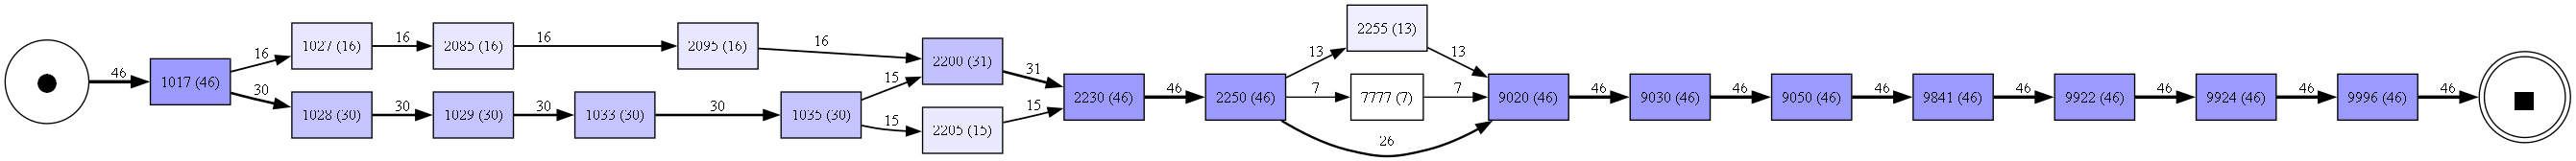

In [14]:
dfg, start, end = pm4py.discover_dfg(log)
pm4py.view_dfg(dfg, start, end)


## Split Miner BPMN (full log)

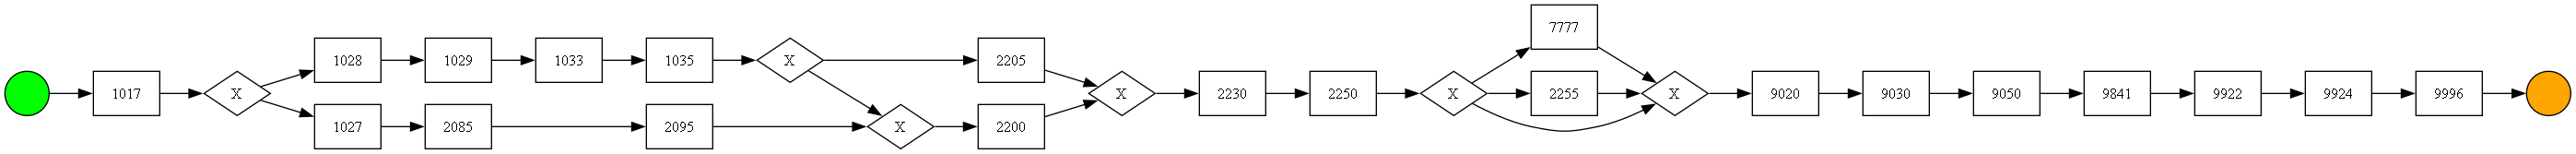

In [15]:
bpmn_full = split_miner.apply(log)
pm4py.view_bpmn(bpmn_full)


## Unify PROCESSAREA below threshold

For each OPERATION, find the dominant PROCESSAREA. If it accounts for
more than `THRESHOLD` of occurrences, rewrite minority values to match.

In [16]:
log_raw = log.copy()

THRESHOLD = 0.9

changed = 0
for oper, grp in log.groupby("concept:name"):
    counts = grp["PROCESSAREA"].value_counts()
    dominant = counts.index[0]
    frac = counts.iloc[0] / counts.sum()
    if frac >= THRESHOLD:
        mask = log["concept:name"] == oper
        minority = log.loc[mask, "PROCESSAREA"] != dominant
        changed += minority.sum()
        log.loc[mask & minority, "PROCESSAREA"] = dominant

print(f"Unified {changed} events by threshold (threshold={THRESHOLD:.0%})")
print(f"PROCESSAREAs after: {sorted(log['PROCESSAREA'].unique())}")

Unified 3 events by threshold (threshold=90%)
PROCESSAREAs after: ['DDE3', 'LC3', 'PRE']


## Split traces at PROCESSAREA change boundaries

Each wafer trace visits multiple PROCESSAREAs (PRE, DDE3, LC3) in sequence.
To discover a process model per PROCESSAREA, we split every trace into
**sublogs** — one per consecutive run of the same PROCESSAREA. Every change
of PROCESSAREA boundary produces a new sublog. A trace like
PRE → DDE3 → LC3 → PRE yields **four** sublogs, not one per area.

**Smoothing** single-operation outliers are ignored for splitting.
If operation X has PROCESSAREA A but both neighbours agree on B,
X is treated as B for split detection (its original PROCESSAREA is
preserved in the output).

**Example:** trace `PF-MONV3 / 14389044`:

```
ROUTEOPER  1017  1028  1029  1033  1035  2200  2230  2250  9020  9030  9050  9841  9922  9924  9996
PROCESS     PRE   PRE   PRE   PRE  DDE3   PRE   PRE  DDE3  DDE3  DDE3   LC3   LC3   PRE   PRE   PRE
smoothed    PRE   PRE   PRE   PRE   PRE   PRE   PRE  DDE3  DDE3  DDE3   LC3   LC3   PRE   PRE   PRE
          |------------ seg0 (PRE) ---------------|--- seg1 (DDE3) ---|-- seg2 --|---- seg3 (PRE) ----|
```

- `1035: DDE3` is a single blip between PRE operations → smoothed, no split.
- Each sublog gets a unique case ID (`{orig_case}_seg{N}`) and retains
  its smoothed PROCESSAREA for the per-area Split Miner.

In [17]:
rows = []
for case_id, trace in log.groupby("case:concept:name"):
    trace = trace.sort_values("ROUTEOPERORDER").reset_index(drop=True)
    areas = trace["PROCESSAREA"].tolist()

    # smooth out single-operation outliers: if an operation differs
    # from both neighbours (which agree), treat it as the neighbour
    # value for split-point detection
    smoothed = list(areas)
    op_names = trace["concept:name"].tolist()
    for i in range(1, len(smoothed) - 1):
        if smoothed[i] != smoothed[i-1] and smoothed[i] != smoothed[i+1] and smoothed[i-1] == smoothed[i+1]:
            # print(f"Case {case_id}: smoothing {smoothed[i]} to {smoothed[i-1]} in operation {op_names[i]} (neighbors: {smoothed[i-1]}, {smoothed[i+1]})")
            smoothed[i] = smoothed[i-1]

    split_at = set()
    for i in range(1, len(smoothed)):
        if smoothed[i] != smoothed[i - 1]:
            split_at.add(i)

    seg_idx = 0
    for i, (_, ev) in enumerate(trace.iterrows()):
        if i in split_at:
            seg_idx += 1
        rows.append({
            "case:concept:name": f"{case_id}_seg{seg_idx}",
            "concept:name": ev["concept:name"],
            "time:timestamp": ev["time:timestamp"],
            "ROUTEOPERORDER": ev["ROUTEOPERORDER"],
            "PROCESSAREA": smoothed[i],
            "_orig_case": case_id,
            "_seg_idx": seg_idx,
        })

split_df = pd.DataFrame(rows)
n_sublogs = split_df["case:concept:name"].nunique()
print(f"Original traces: {log['case:concept:name'].nunique()}")
print(f"Sublogs after split: {n_sublogs}")
print(f"\nSublogs per PROCESSAREA change boundary:")
for (seg_idx, area), grp in split_df.groupby(["_seg_idx", "PROCESSAREA"]):
    print(f"  seg{seg_idx} ({area}): {grp['case:concept:name'].nunique()} sublogs, {len(grp)} events")


Original traces: 46
Sublogs after split: 184

Sublogs per PROCESSAREA change boundary:
  seg0 (PRE): 46 sublogs, 306 events
  seg1 (DDE3): 46 sublogs, 204 events
  seg2 (LC3): 46 sublogs, 46 events
  seg3 (PRE): 46 sublogs, 138 events


## Split Miner BPMN per PROCESSAREA

  seg0 (PRE): 46 sublogs, 306 events


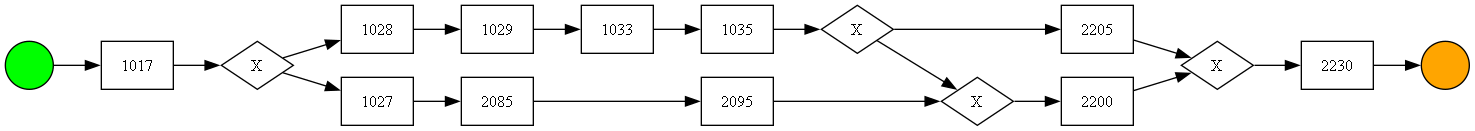

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/11 [00:00<?, ?it/s]

  Fitness: 1.0000  Precision: 1.0000
  Variants allowed by model (3 variants, 46 sublogs):
    [ 16x] 1017 (PRE) -> 1027 (PRE) -> 2085 (PRE) -> 2095 (DDE3) -> 2200 (PRE) -> 2230 (PRE)
    [ 15x] 1017 (PRE) -> 1028 (PRE) -> 1029 (PRE) -> 1033 (PRE) -> 1035 (DDE3) -> 2200 (PRE) -> 2230 (PRE)
    [ 15x] 1017 (PRE) -> 1028 (PRE) -> 1029 (PRE) -> 1033 (PRE) -> 1035 (DDE3) -> 2205 (PRE) -> 2230 (PRE)
  Variants not allowed by model (0 variants, 0 sublogs):

  seg1 (DDE3): 46 sublogs, 204 events


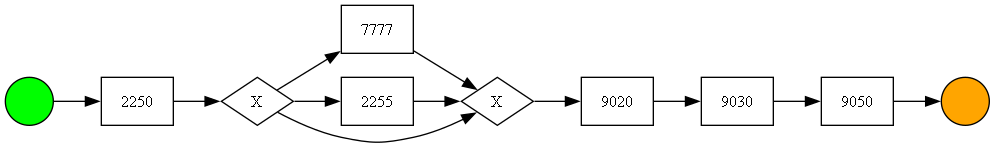

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/9 [00:00<?, ?it/s]

  Fitness: 1.0000  Precision: 1.0000
  Variants allowed by model (3 variants, 46 sublogs):
    [ 26x] 2250 (DDE3) -> 9020 (DDE3) -> 9030 (DDE3) -> 9050 (DDE3)
    [ 13x] 2250 (DDE3) -> 2255 (DDE3) -> 9020 (DDE3) -> 9030 (DDE3) -> 9050 (DDE3)
    [  7x] 2250 (DDE3) -> 7777 (DDE3) -> 9020 (DDE3) -> 9030 (DDE3) -> 9050 (DDE3)
  Variants not allowed by model (0 variants, 0 sublogs):

  seg2 (LC3): 46 sublogs, 46 events


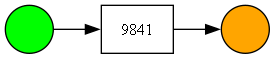

  Fitness: 1.0000  Precision: 1.0000
  Variants allowed by model (1 variants, 46 sublogs):
    [ 46x] 9841 (LC3)
  Variants not allowed by model (0 variants, 0 sublogs):

  seg3 (PRE): 46 sublogs, 138 events


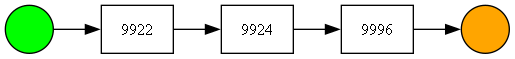

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

  Fitness: 1.0000  Precision: 1.0000
  Variants allowed by model (1 variants, 46 sublogs):
    [ 46x] 9922 (PRE) -> 9924 (PRE) -> 9996 (PRE)
  Variants not allowed by model (0 variants, 0 sublogs):



In [18]:
# Map each operation to its original PROCESSAREA (dominant area from raw log)
orig_area_map = {}
for oper, grp in log_raw.groupby("concept:name"):
    orig_area_map[oper] = grp["PROCESSAREA"].value_counts().index[0]

for (seg_idx, area), grp in split_df.groupby(["_seg_idx", "PROCESSAREA"]):

    sub_df = grp.copy()
    n_cases = sub_df["case:concept:name"].nunique()
    print(f"  seg{seg_idx} ({area}): {n_cases} sublogs, {len(sub_df)} events")

    bpmn = split_miner.apply(sub_df)
    pm4py.view_bpmn(bpmn)

    net, im, fm = pm4py.convert_to_petri_net(bpmn)
    ev_log = pm4py.convert_to_event_log(sub_df)
    fitness = pm4py.fitness_token_based_replay(ev_log, net, im, fm)["log_fitness"]
    precision = pm4py.precision_token_based_replay(ev_log, net, im, fm)
    print(f"  Fitness: {fitness:.4f}  Precision: {precision:.4f}")

    variants = sub_df.sort_values("ROUTEOPERORDER").groupby("case:concept:name")["concept:name"].apply(tuple).value_counts().sort_values(ascending=False)

    allowed, not_allowed = [], []
    for seq, count in variants.items():
        vdf = pd.DataFrame({
            "case:concept:name": ["v0"] * len(seq),
            "concept:name": list(seq),
            "time:timestamp": pd.date_range("2024-01-01", periods=len(seq), freq="s"),
        })
        vlog = pm4py.convert_to_event_log(vdf)
        f = pm4py.fitness_token_based_replay(vlog, net, im, fm)["log_fitness"]
        (allowed if f == 1.0 else not_allowed).append((seq, count))

    def fmt_seq(s):
        return ' -> '.join(f'{n} ({orig_area_map[n]})' for n in s)

    print(f"  Variants allowed by model ({len(allowed)} variants, {sum(c for _,c in allowed)} sublogs):")
    for seq, count in allowed:
        print(f"    [{count:3d}x] {fmt_seq(seq)}")
    print(f"  Variants not allowed by model ({len(not_allowed)} variants, {sum(c for _,c in not_allowed)} sublogs):")
    for seq, count in not_allowed:
        print(f"    [{count:3d}x] {fmt_seq(seq)}")
    print('='* 100)
    print()


## Abstracted event log

Replace each sublog with its PROCESSAREA + variant index.
For example, a PRE sublog matching variant `9922 -> 9924 -> 9996`
becomes `PRE_v0`, a DDE3 sublog matching `1017 -> 1028 -> 1029 -> 1033 -> 1035 -> 2200 -> 2230`
becomes `DDE3_v1`, etc.  The result is a compact event log where each
event represents a whole PROCESSAREA visit.

In [19]:
# Build variant labels per PROCESSAREA — only variants allowed by the discovered model
variant_map = {}
dropped = 0
for group_name in sorted(split_df["PROCESSAREA"].unique()):
    sub_df = split_df[split_df["PROCESSAREA"] == group_name].copy()
    bpmn = split_miner.apply(sub_df)
    net, im, fm = pm4py.convert_to_petri_net(bpmn)
    variants = sub_df.sort_values("ROUTEOPERORDER").groupby("case:concept:name")["concept:name"].apply(tuple).value_counts()
    idx = 0
    for seq in variants.index:
        vdf = pd.DataFrame({
            "case:concept:name": ["v0"] * len(seq),
            "concept:name": list(seq),
            "time:timestamp": pd.date_range("2024-01-01", periods=len(seq), freq="s"),
        })
        vlog = pm4py.convert_to_event_log(vdf)
        f = pm4py.fitness_token_based_replay(vlog, net, im, fm)["log_fitness"]
        if f == 1.0:
            variant_map[(group_name, seq)] = f"{group_name}_v{idx}"
            idx += 1
        else:
            dropped += 1

print(f"Variant labels: {len(variant_map)} (dropped {dropped} model-rejected variants)")
for (area, seq), label in sorted(variant_map.items()):
    print(f"  {label}: {' -> '.join(seq)}")

Variant labels: 8 (dropped 0 model-rejected variants)
  DDE3_v1: 2250 -> 2255 -> 9020 -> 9030 -> 9050
  DDE3_v2: 2250 -> 7777 -> 9020 -> 9030 -> 9050
  DDE3_v0: 2250 -> 9020 -> 9030 -> 9050
  LC3_v0: 9841
  PRE_v1: 1017 -> 1027 -> 2085 -> 2095 -> 2200 -> 2230
  PRE_v2: 1017 -> 1028 -> 1029 -> 1033 -> 1035 -> 2200 -> 2230
  PRE_v3: 1017 -> 1028 -> 1029 -> 1033 -> 1035 -> 2205 -> 2230
  PRE_v0: 9922 -> 9924 -> 9996


Abstracted log: 46 traces, 184 events, 6 variants
Activities: ['DDE3_v0', 'DDE3_v1', 'DDE3_v2', 'LC3_v0', 'PRE_v0', 'PRE_v1', 'PRE_v2', 'PRE_v3']


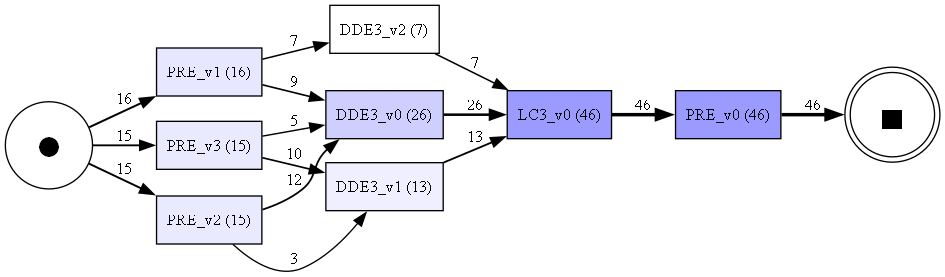

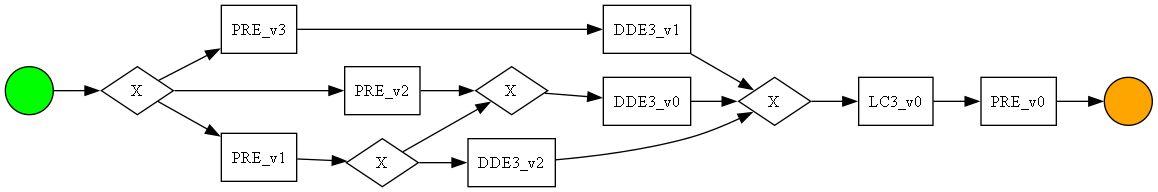

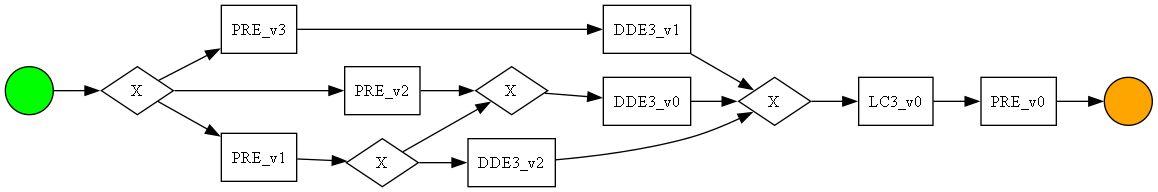

In [20]:
from pm4py.objects.conversion.log import converter as log_converter

# Assign abstract activity to each segment
def label_segment(row):
    seq = tuple()
    return variant_map.get((row["PROCESSAREA"], seq), row["PROCESSAREA"])

# Build segment-level labels: group by (orig_case, seg_idx), get operation sequence
seg_labels = []
for (case_id, seg_idx), grp in split_df.groupby(["_orig_case", "_seg_idx"]):
    grp = grp.sort_values("ROUTEOPERORDER")
    seq = tuple(grp["concept:name"])
    area = grp["PROCESSAREA"].iloc[0]
    label = variant_map.get((area, seq), f"{area}_unknown")
    seg_labels.append({
        "case:concept:name": case_id,
        "concept:name": label,
        "time:timestamp": grp["time:timestamp"].iloc[0],
        "PROCESSAREA": area,
    })

abstract_df = pd.DataFrame(seg_labels)
abstract_log = pm4py.convert_to_event_log(abstract_df)

n_cases = abstract_df["case:concept:name"].nunique()
variants_abs = abstract_df.groupby("case:concept:name")["concept:name"].apply(tuple).value_counts()
print(f"Abstracted log: {n_cases} traces, {len(abstract_df)} events, {len(variants_abs)} variants")
print(f"Activities: {sorted(abstract_df['concept:name'].unique())}")

# Mine dfg
dfg, start, end = pm4py.discover_dfg(abstract_log)
pm4py.view_dfg(dfg, start, end)

# Mine with Split Miner (default params)
bpmn_abs = split_miner.apply(abstract_log)
pm4py.view_bpmn(bpmn_abs)

# Mine with Split Miner (custom params)
bpmn_custom = pm4py.discover_bpmn_split_miner(abstract_log, eta=0.2, epsilon=0)
pm4py.view_bpmn(bpmn_custom)



In [21]:
# Evaluate both models
def evaluate_model(ev_log, bpmn_model):
    net, im, fm = pm4py.convert_to_petri_net(bpmn_model)
    fitness = pm4py.fitness_token_based_replay(ev_log, net, im, fm)["log_fitness"]
    precision = pm4py.precision_token_based_replay(ev_log, net, im, fm)
    f1 = 2 * fitness * precision / (fitness + precision) if (fitness + precision) else 0.0
    return fitness, precision, f1

print("=" * 65)
print(f"{'Params':<25} {'Fitness':>10} {'Precision':>10} {'F1':>10}")
print("=" * 65)
for label, bpmn_model in [("default (e=0.1, η=0.4)", bpmn_abs),
                           ("custom  (e=0, η=0.2)", bpmn_custom)]:
    fitness, precision, f1 = evaluate_model(abstract_log, bpmn_model)
    print(f"{label:<25} {fitness:>10.4f} {precision:>10.4f} {f1:>10.4f}")
print("=" * 65)

Params                       Fitness  Precision         F1


replaying log with TBR, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15 [00:00<?, ?it/s]

default (e=0.1, η=0.4)        0.9719     1.0000     0.9858


replaying log with TBR, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/15 [00:00<?, ?it/s]

custom  (e=0, η=0.2)          0.9719     1.0000     0.9858
